In [1]:
import pandas as pd

X_train = pd.read_csv("X_train_processed.csv")
X_test = pd.read_csv("X_test_processed.csv")
y_train = pd.read_csv("y_train_processed.csv").squeeze()
y_test = pd.read_csv("y_test_processed.csv").squeeze()

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(5634, 23) (1409, 23)
0.2653532126375577 0.2654364797728886


In [22]:
shap.initjs()

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_estimators=200
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [5]:
import joblib
joblib.dump(rf_model, "churn_model.pkl")
print("Model was trained on these columns:", list(rf_model.feature_names_in_))

Model was trained on these columns: ['SeniorCitizen', 'tenure', 'TotalCharges', 'gender_Male', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'HouseholdType_Neither', 'HouseholdType_Partner + Dependents', 'HouseholdType_Partner only']


Confusion Matrix:
[[931 104]
 [187 187]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


ROC-AUC Score: 0.8252


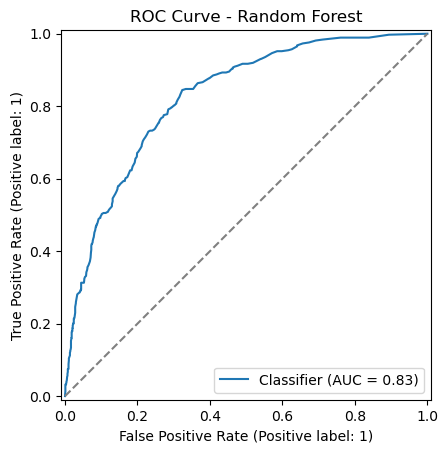

In [3]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)

# Precision, recall, F1
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# ROC-AUC score
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"\nROC-AUC Score: {auc_rf:.4f}")

# ROC curve plot
RocCurveDisplay.from_predictions(y_test, y_pred_proba_rf)
plt.title("ROC Curve - Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.show()

In [4]:
from sklearn.metrics import precision_recall_curve, classification_report

# Try a few different thresholds and compare recall/precision for class 1
thresholds_to_test = [0.5, 0.4, 0.35, 0.3, 0.25, 0.2]

for t in thresholds_to_test:
    y_pred_t = (y_pred_proba_rf >= t).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True)
    print(f"Threshold: {t}")
    print(f"  Recall (churn):    {report['1']['recall']:.3f}")
    print(f"  Precision (churn): {report['1']['precision']:.3f}")
    print(f"  F1 (churn):        {report['1']['f1-score']:.3f}")
    print()

Threshold: 0.5
  Recall (churn):    0.503
  Precision (churn): 0.642
  F1 (churn):        0.564

Threshold: 0.4
  Recall (churn):    0.594
  Precision (churn): 0.571
  F1 (churn):        0.582

Threshold: 0.35
  Recall (churn):    0.655
  Precision (churn): 0.549
  F1 (churn):        0.598

Threshold: 0.3
  Recall (churn):    0.730
  Precision (churn): 0.534
  F1 (churn):        0.617

Threshold: 0.25
  Recall (churn):    0.778
  Precision (churn): 0.500
  F1 (churn):        0.609

Threshold: 0.2
  Recall (churn):    0.848
  Precision (churn): 0.479
  F1 (churn):        0.612



In [5]:
!pip install shap

In [8]:
import shap

# Create the explainer for the tree-based model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

In [7]:
import shap

explainer = shap.TreeExplainer(rf_model)

# Test on just 100 rows first, to confirm speed and correctness
X_test_sample = X_test.sample(100, random_state=42)
shap_values_sample = explainer.shap_values(X_test_sample)

print("Done!")

Done!


In [10]:
shap_values.shape

(1409, 23, 2)

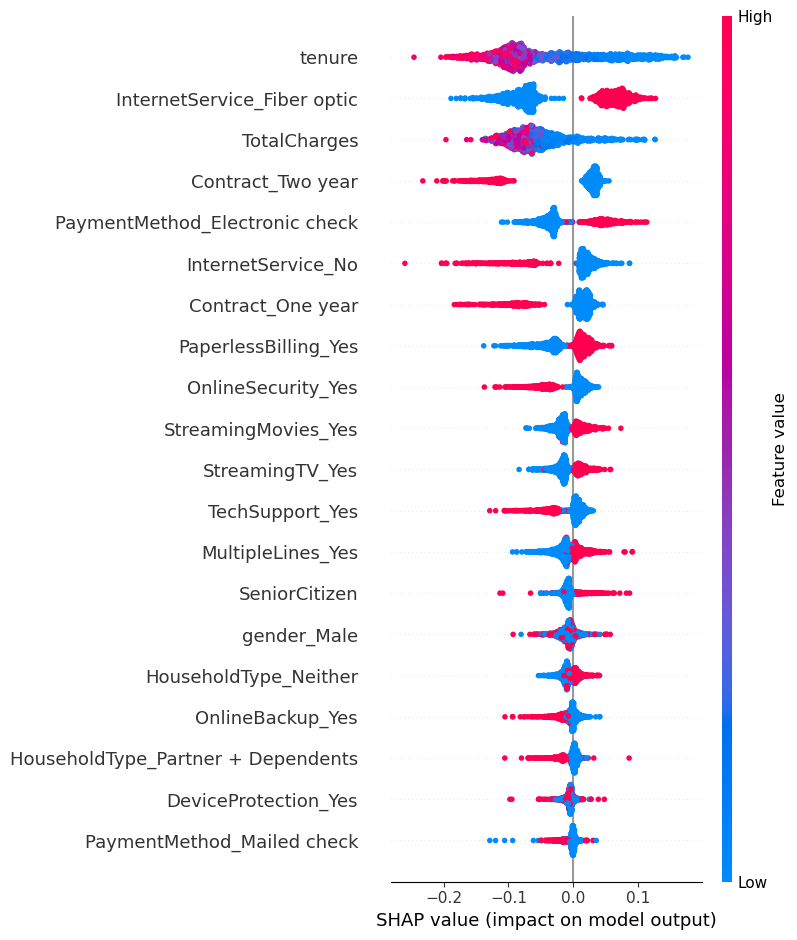

In [11]:
import matplotlib.pyplot as plt

# Global feature importance / direction
shap.summary_plot(shap_values[:,:,1], X_test)  # index 1 = "churn" class for binary RF

In [12]:
shap_values_churn = shap_values[:, :, 1]  # class 1 = churn

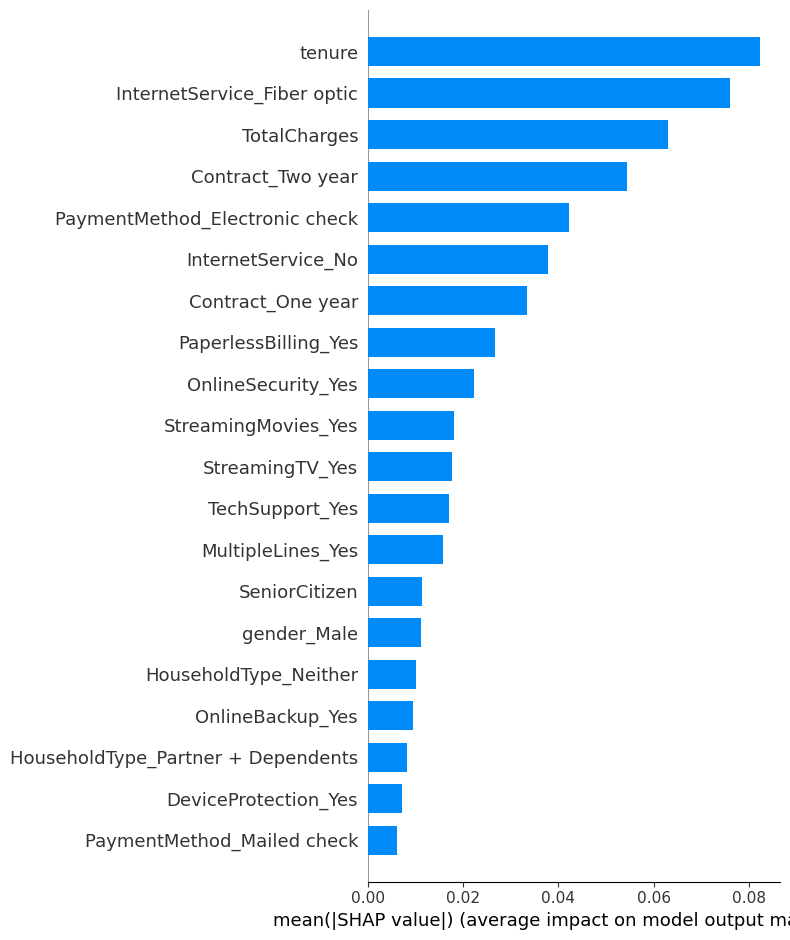

In [13]:
shap.summary_plot(shap_values_churn, X_test, plot_type="bar")

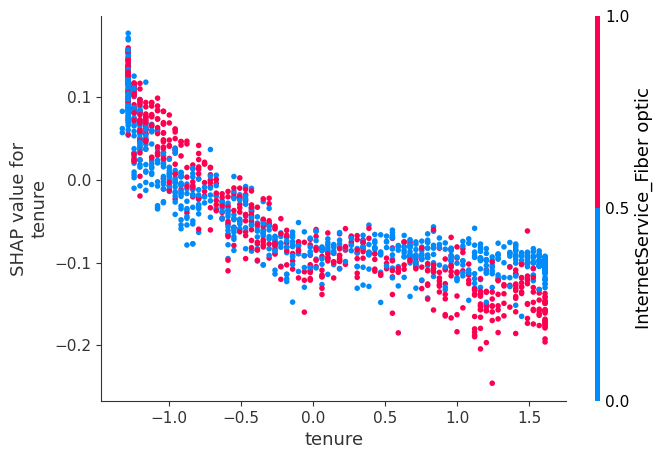

In [21]:
shap.dependence_plot("tenure", shap_values_churn, X_test)

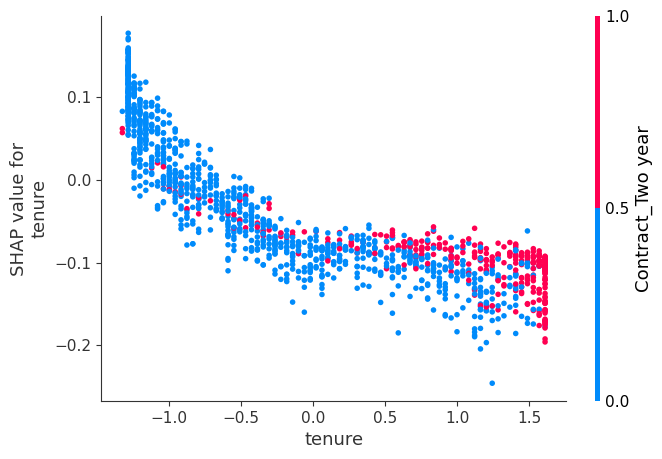

In [15]:
shap.dependence_plot("tenure", shap_values_churn, X_test, interaction_index="Contract_Two year")

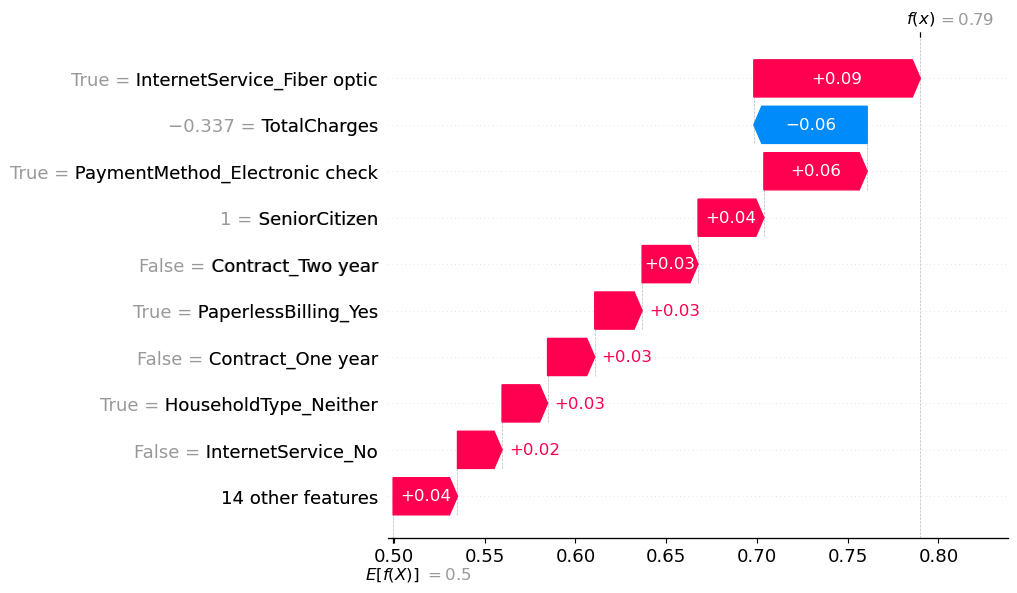

In [26]:
explainer_out = explainer(X_test)  # newer API, returns an Explanation object
shap.plots.waterfall(explainer_out[:, :, 1][100])  # first customer, churn class

In [25]:
shap.plots.force(explainer_out[100, :, 1])

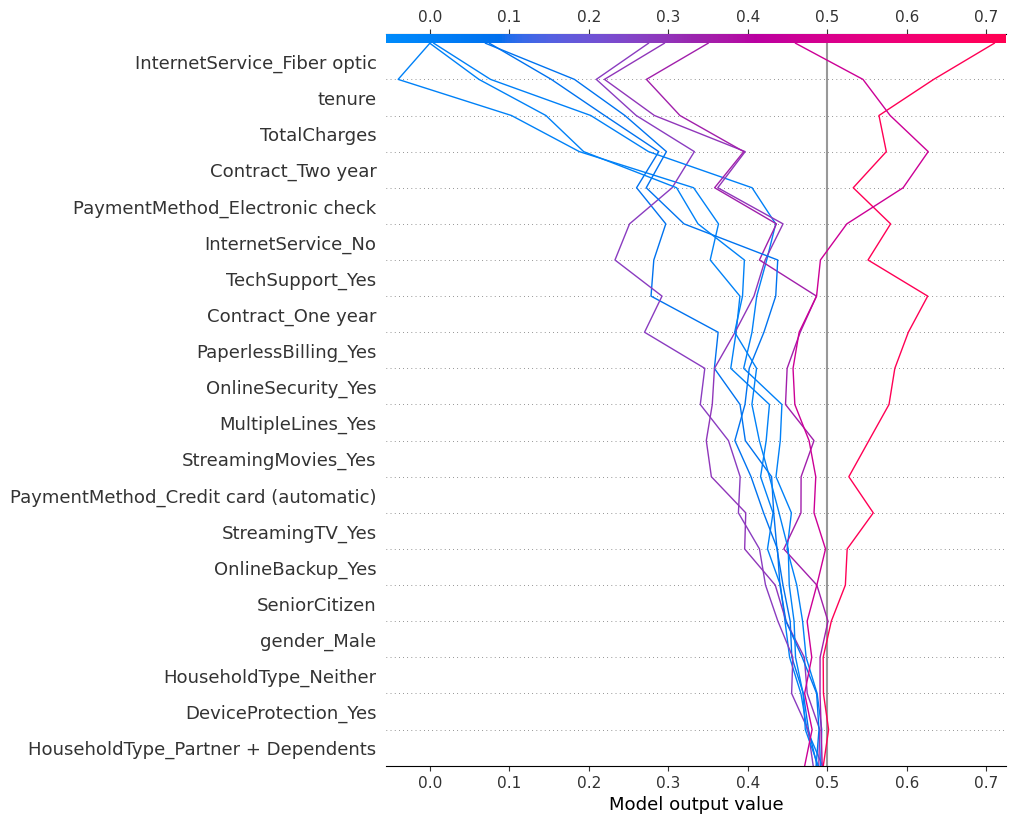

In [18]:
shap.decision_plot(explainer.expected_value[1], shap_values_churn[:10], X_test.iloc[:10])

In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="roc_auc")
print("CV ROC-AUC scores:", cv_scores)
print("Mean:", cv_scores.mean(), "Std:", cv_scores.std())

CV ROC-AUC scores: [0.83928312 0.82411581 0.82257687 0.81769546 0.8049504 ]
Mean: 0.8217243308365134 Std: 0.011066649012063568


In [28]:
import joblib
joblib.dump(rf_model, "churn_model.pkl")

['churn_model.pkl']